<a href="https://colab.research.google.com/github/thasnissam/NorthStar_Data_Analytics_Project/blob/main/Notebooks/NorthStar_R_SQL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Data

In [29]:
# Install and load packages
install.packages(c('sqldf','ggplot2','dplyr','tidyr','lubridate','scales'))
library(sqldf)
library(ggplot2)
library(dplyr)
library(tidyr)
library(lubridate)
library(scales)

# Import all CSV files
customers   <- read.csv('customers.csv', stringsAsFactors = FALSE)
orders      <- read.csv('orders.csv', stringsAsFactors = FALSE)
deliveries  <- read.csv('deliveries.csv', stringsAsFactors = FALSE)
drivers     <- read.csv('drivers.csv', stringsAsFactors = FALSE)
vehicles    <- read.csv('vehicles.csv', stringsAsFactors = FALSE)
hubs        <- read.csv('hubs.csv', stringsAsFactors = FALSE)
complaints  <- read.csv('complaints.csv', stringsAsFactors = FALSE)
incidents   <- read.csv('incidents.csv', stringsAsFactors = FALSE)
app_events  <- read.csv('app_events.csv', stringsAsFactors = FALSE)

head(customers)
head(orders)
head(deliveries)
head(drivers)
head(vehicles)
head(hubs)
head(complaints)
head(incidents)
head(app_events)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
2,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
3,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,,Active
4,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
5,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
6,C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<int>
1,D001,AIRPORT,FullTime,8,67.8,3.54,Morning,1
2,D002,Central,FullTime,4,42.4,3.94,Evening,1
3,D003,AIRPORT,FullTime,11,96.5,5.00,Evening,1
4,D004,Airport,PartTime,13,88.9,4.75,Morning,1
5,D005,north,FullTime,3,69.7,4.14,Morning,1
6,D006,CENTRAL,FullTime,8,78.8,4.38,Flexible,1


,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>
1,V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
2,V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
3,V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1
4,V004,Hybrid,RiverSide,2024-06-07 13:21:00,NA,36310,Active,v2.2
5,V005,CargoVan,West,2025-11-15 11:08:00,58.6,146638,Active,v2.2
6,V006,EV,Central,2025-11-22 06:39:00,78.6,141381,Active,v2.1


,hub_id,hub_name,zone,hub_type,capacity_score
,<chr>,<chr>,<chr>,<chr>,<int>
1,H01,North Exchange,North,Dispatch,82
2,H02,South Link,South,Dispatch,78
3,H03,East Dock,East,Warehouse,74
4,H04,West Gate,West,Dispatch,69
5,H05,Central Core,Central,Control,88
6,H06,Airport Hub,Airport,Dispatch,71


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
1,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
2,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
3,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
4,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
5,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
6,CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
2,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
3,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
4,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
5,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0
6,I0006,DL00634,CustomerNoShow,2025-08-08 21:26:00,High,PendingVendor,19.9


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
1,AE00001,C0488,,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
2,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
3,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1
4,AE00004,C0407,O00756,2025-08-23 17:38:00,eta_refresh,S41236,iOS,CENTRAL,442,1
5,AE00005,C0506,,2024-05-29 10:33:00,search_route,S12030,iOS,north,60,1
6,AE00006,C0498,O01196,2025-02-08 09:50:00,track_order,S66655,Web,West,499,1


Data cleaning and categorical standardisation

In [36]:
# --- DATA STANDARDISATION AND CLEANING ---

# 1. Normalise string formats: Remove accidental spaces (trimws) and unify case
# This prevents duplicates like "Central" vs " CENTRAL" vs "CENTRAL"
orders$pickup_zone      <- trimws(toupper(orders$pickup_zone))
orders$dropoff_zone     <- trimws(toupper(orders$dropoff_zone))
drivers$base_zone       <- trimws(toupper(drivers$base_zone))
vehicles$assigned_zone  <- trimws(toupper(vehicles$assigned_zone))
customers$home_zone     <- trimws(toupper(customers$home_zone))

# Standardise complaint channels to lowercase for consistent grouping
complaints$channel <- trimws(tolower(complaints$channel))

# Unify maintenance labels to uppercase
vehicles$maintenance_status <- trimws(toupper(vehicles$maintenance_status))

# Merge orders information into deliveries to get pickup_zone
deliveries <- deliveries %>%
  left_join(orders %>% select(order_id, pickup_zone), by = "order_id")

# 2. Logic Mapping: Merging variations into a single "Source of Truth"
# This addresses the 'System Inconsistency' mentioned in the NorthStar case study.
orders$pickup_zone <- dplyr::case_when(
  # Group shorthand 'CTR' and variations like 'CENTRE' into the official 'CENTRAL' name
  orders$pickup_zone %in% c("CTR", "CENTRE") ~ "CENTRAL",
  TRUE ~ orders$pickup_zone
)

deliveries$pickup_zone <- dplyr::case_when(
  deliveries$pickup_zone %in% c("CTR", "CENTRE") ~ "CENTRAL",
  deliveries$pickup_zone %in% c("RIVERSIDE", "RIVERSIDE ") ~ "RIVERSIDE",
  deliveries$pickup_zone %in% c("NORTH") ~ "NORTH",
  deliveries$pickup_zone %in% c("SOUTH") ~ "SOUTH",
  deliveries$pickup_zone %in% c("EAST") ~ "EAST",
  deliveries$pickup_zone %in% c("WEST") ~ "WEST",
  deliveries$pickup_zone %in% c("AIRPORT") ~ "AIRPORT",
  TRUE ~ deliveries$pickup_zone
)

drivers$base_zone <- dplyr::case_when(
  drivers$base_zone %in% c("CTR", "CENTRE") ~ "CENTRAL",
  TRUE ~ drivers$base_zone
)

Dataset dimensions and table overview

In [8]:
cat("=== DATASET DIMENSIONS ===\n")
cat("Orders: ", nrow(orders), "rows,", ncol(orders), "columns\n")
cat("Deliveries: ", nrow(deliveries), "rows,", ncol(deliveries), "columns\n")
cat("Customers: ", nrow(customers), "rows,", ncol(customers), "columns\n")
cat("Drivers: ", nrow(drivers), "rows,", ncol(drivers), "columns\n")
cat("Vehicles: ", nrow(vehicles), "rows,", ncol(vehicles), "columns\n")
cat("Complaints: ", nrow(complaints), "rows,", ncol(complaints), "columns\n")
cat("Incidents: ", nrow(incidents), "rows,", ncol(incidents), "columns\n")
cat("Hubs: ", nrow(hubs), "rows,", ncol(hubs), "columns\n")

=== DATASET DIMENSIONS ===
Orders:  1250 rows, 11 columns
Deliveries:  950 rows, 13 columns
Customers:  650 rows, 9 columns
Drivers:  170 rows, 8 columns
Vehicles:  120 rows, 8 columns
Complaints:  320 rows, 10 columns
Incidents:  280 rows, 7 columns
Hubs:  8 rows, 5 columns


Structural inspection and data types

In [9]:
cat("=== ORDERS STRUCTURE ===\n")
str(orders)

cat("\n=== DELIVERIES STRUCTURE ===\n")
str(deliveries)

cat("\n=== COMPLAINTS STRUCTURE ===\n")
str(complaints)

=== ORDERS STRUCTURE ===
'data.frame':	1250 obs. of  11 variables:
 $ order_id             : chr  "O00001" "O00002" "O00003" "O00004" ...
 $ customer_id          : chr  "C0292" "C0459" "C0161" "C0520" ...
 $ service_type         : chr  "Passenger" "Passenger" "Passenger" "Parcel" ...
 $ order_created_at     : chr  "2024-08-20 14:43:00" "2024-05-14 22:16:00" "2025-09-02 14:37:00" "2025-01-11 17:15:00" ...
 $ promised_window_hours: int  6 24 4 2 12 1 2 4 12 6 ...
 $ pickup_zone          : chr  "AIRPORT" "NORTH" "WEST" "RIVERSIDE" ...
 $ dropoff_zone         : chr  "SOUTH" "AIRPORT" "AIRPORT" "NORTH" ...
 $ priority_level       : chr  "Medium" "Low" "High" "Medium" ...
 $ order_value          : num  126.7 109.3 33.5 10 125.6 ...
 $ booking_channel      : chr  "App" "App" "Phone" "App" ...
 $ special_handling_flag: int  0 0 0 1 0 1 0 0 0 0 ...

=== DELIVERIES STRUCTURE ===
'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004

Missing value analysis

Missing values by table

In [10]:
count_missing <- function(df, name) {
  total <- sum(is.na(df))
  cat(name, "— missing values:", total, "\n")
}

cat("=== MISSING VALUES PER TABLE ===\n")
count_missing(orders, "Orders")
count_missing(deliveries, "Deliveries")
count_missing(customers, "Customers")
count_missing(drivers, "Drivers")
count_missing(vehicles, "Vehicles")
count_missing(complaints, "Complaints")
count_missing(incidents, "Incidents")

=== MISSING VALUES PER TABLE ===
Orders — missing values: 0 
Deliveries — missing values: 14 
Customers — missing values: 20 
Drivers — missing values: 7 
Vehicles — missing values: 4 
Complaints — missing values: 16 
Incidents — missing values: 17 


missing values by column

In [30]:
colSums(is.na(deliveries))
colSums(is.na(customers))
colSums(is.na(drivers))
colSums(is.na(vehicles))
colSums(is.na(complaints))
colSums(is.na(incidents))

delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at               delivery_status 
                            0                             0 
            route_distance_km   manual_route_override_count 
                            0                             0 
  proof_of_completion_missing customer_rating_post_delivery 
                            0                            14 
          fuel_or_charge_cost 
                            0

customer_id                  age            home_zone 
                   0                    0                    0 
       customer_type          signup_date        loyalty_score 
                   0                    0                   20 
app_engagement_score    preferred_channel       account_status 
                   0                    0                    0

driver_id        base_zone  employment_type years_experience 
               0                0                0                0 
  training_score    driver_rating shift_preference      active_flag 
               7                0                0                0

vehicle_id       vehicle_type      assigned_zone    commission_date 
                 0                  0                  0                  0 
battery_health_pct        odometer_km maintenance_status telematics_version 
                 4                  0                  0                  0

complaint_id         customer_id            order_id      complaint_type 
                  0                   0                   0                   0 
            channel            severity          created_at              status 
                  0                   0                   0                   0 
    resolution_days compensation_amount 
                  0                  16

incident_id       delivery_id     incident_type       reported_at 
                0                 0                 0                 0 
         severity resolution_status    resolved_hours 
                0                 0                17

Missing values treatment

In [37]:
# Categorical fields
deliveries$delivery_status[is.na(deliveries$delivery_status)] <- "Unknown"
deliveries$pickup_zone[is.na(deliveries$pickup_zone)] <- "Unknown"
complaints$channel[is.na(complaints$channel)] <- "Unknown"
vehicles$maintenance_status[is.na(vehicles$maintenance_status)] <- "Unknown"

# Numeric fields
deliveries$route_distance_km[is.na(deliveries$route_distance_km)] <- median(deliveries$route_distance_km, na.rm = TRUE)
deliveries$fuel_or_charge_cost[is.na(deliveries$fuel_or_charge_cost)] <- median(deliveries$fuel_or_charge_cost, na.rm = TRUE)
complaints$compensation_amount[is.na(complaints$compensation_amount)] <- median(complaints$compensation_amount, na.rm = TRUE)

# Missingness flags
deliveries$distance_missing_flag <- ifelse(is.na(deliveries$route_distance_km), 1, 0)
complaints$comp_missing_flag <- ifelse(is.na(complaints$compensation_amount), 1, 0)

Duplicate analysis

In [12]:
duplicate_check <- function(df, name) {
  dup_count <- sum(duplicated(df))
  cat(name, "— duplicate rows:", dup_count, "\n")
}

duplicate_check(orders, "Orders")
duplicate_check(deliveries, "Deliveries")
duplicate_check(customers, "Customers")
duplicate_check(complaints, "Complaints")
duplicate_check(incidents, "Incidents")

Orders — duplicate rows: 0 
Deliveries — duplicate rows: 0 
Customers — duplicate rows: 0 
Complaints — duplicate rows: 0 
Incidents — duplicate rows: 0 


Descriptive statistics for numeric fields

In [13]:
cat("=== ORDERS SUMMARY ===\n")
summary(orders[, c("order_value", "promised_window_hours")])

cat("\n=== DELIVERIES SUMMARY ===\n")
summary(deliveries[, c("route_distance_km", "fuel_or_charge_cost",
                        "customer_rating_post_delivery",
                        "manual_route_override_count")])

cat("\n=== COMPLAINTS SUMMARY ===\n")
summary(complaints[, c("resolution_days", "compensation_amount")])

=== ORDERS SUMMARY ===


  order_value     promised_window_hours
 Min.   :  2.04   Min.   : 1.000       
 1st Qu.: 47.91   1st Qu.: 4.000       
 Median : 76.53   Median : 6.000       
 Mean   : 91.05   Mean   : 7.622       
 3rd Qu.:121.10   3rd Qu.:12.000       
 Max.   :510.06   Max.   :24.000       


=== DELIVERIES SUMMARY ===


 route_distance_km fuel_or_charge_cost customer_rating_post_delivery
 Min.   : 1.200    Min.   : 2.500      Min.   :1.000                
 1st Qu.: 9.135    1st Qu.: 9.925      1st Qu.:3.360                
 Median :12.840    Median :12.645      Median :4.040                
 Mean   :13.909    Mean   :12.841      Mean   :3.865                
 3rd Qu.:16.835    3rd Qu.:15.697      3rd Qu.:4.550                
 Max.   :41.940    Max.   :29.430      Max.   :5.000                
                                       NAs    :14                   
 manual_route_override_count
 Min.   :0.0000             
 1st Qu.:0.0000             
 Median :1.0000             
 Mean   :0.9695             
 3rd Qu.:2.0000             
 Max.   :7.0000             
                            


=== COMPLAINTS SUMMARY ===


 resolution_days  compensation_amount
 Min.   : 1.000   Min.   : 0.000     
 1st Qu.: 3.750   1st Qu.: 8.822     
 Median : 7.000   Median :18.405     
 Mean   : 7.928   Mean   :20.257     
 3rd Qu.:11.000   3rd Qu.:29.145     
 Max.   :25.000   Max.   :61.850     
                  NAs    :16         

In [14]:
cat("=== UNIQUE ZONE VALUES (orders - pickup_zone) ===\n")
print(unique(orders$pickup_zone))

cat("\n=== UNIQUE ZONE VALUES (drivers - base_zone) ===\n")
print(unique(drivers$base_zone))

cat("\n=== UNIQUE MAINTENANCE STATUS (vehicles) ===\n")
print(unique(vehicles$maintenance_status))

cat("\n=== UNIQUE DELIVERY STATUS (deliveries) ===\n")
print(unique(deliveries$delivery_status))

=== UNIQUE ZONE VALUES (orders - pickup_zone) ===
[1] "AIRPORT"   "NORTH"     "WEST"      "RIVERSIDE" "CENTRAL"   "SOUTH"    
[7] "EAST"     

=== UNIQUE ZONE VALUES (drivers - base_zone) ===
[1] "AIRPORT"   "CENTRAL"   "NORTH"     "SOUTH"     "WEST"      "EAST"     
[7] "RIVERSIDE"

=== UNIQUE MAINTENANCE STATUS (vehicles) ===
[1] "Active"    "InRepair"  "Scheduled"

=== UNIQUE DELIVERY STATUS (deliveries) ===
[1] "Failed"  "OnTime"  "Delayed"


Distribution analysis and visualisation

Delivery status distribution
Objective. To determine how service outcomes are distributed across successful, delayed, and failed deliveries.

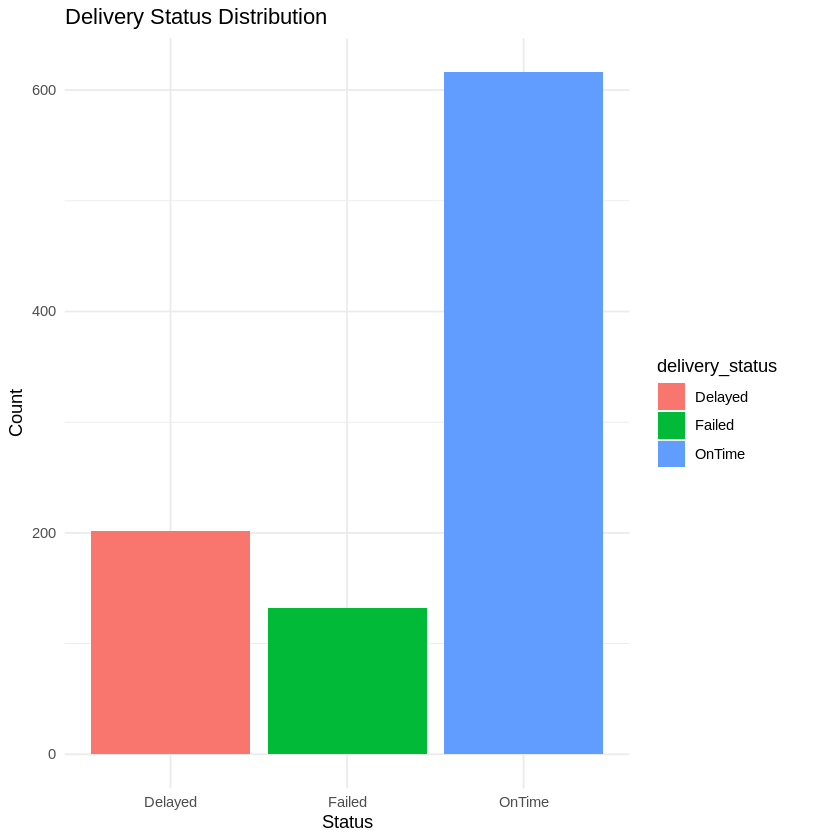

In [15]:
ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  labs(title = "Delivery Status Distribution",
       x = "Status", y = "Count") +
  theme_minimal()

Distribution of order values
Objective. To understand the commercial spread of customer orders and identify whether revenue is concentrated in a small number of transactions.

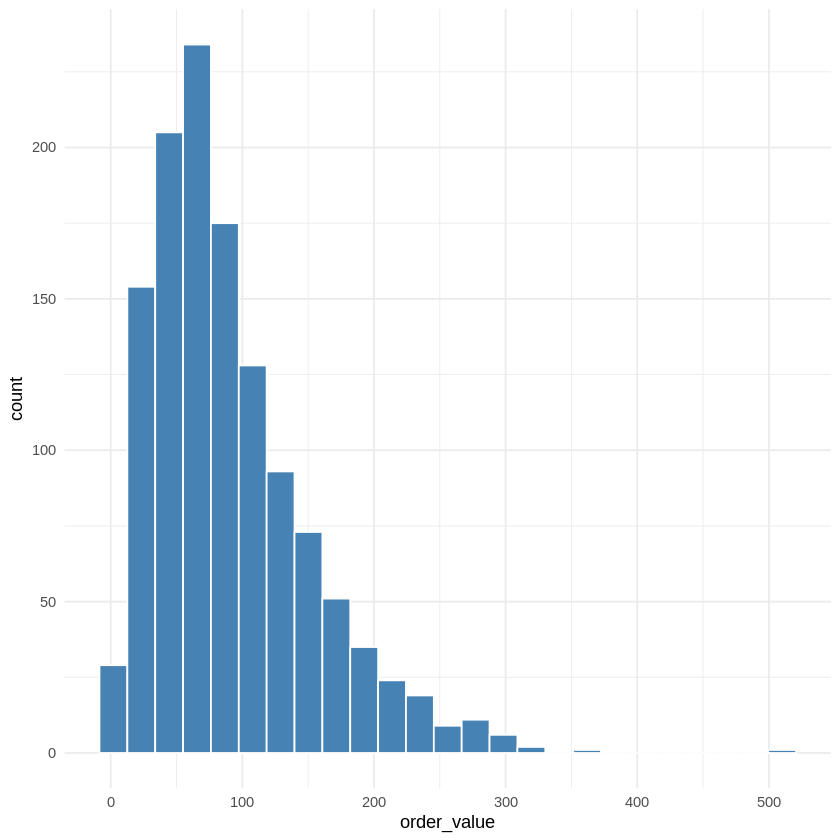

In [16]:
ggplot(orders, aes(x = order_value)) +
  geom_histogram(bins = 25, fill = "steelblue", color = "white") +
  theme_minimal()

Complaint type frequency
Objective. To identify the dominant forms of customer dissatisfaction.


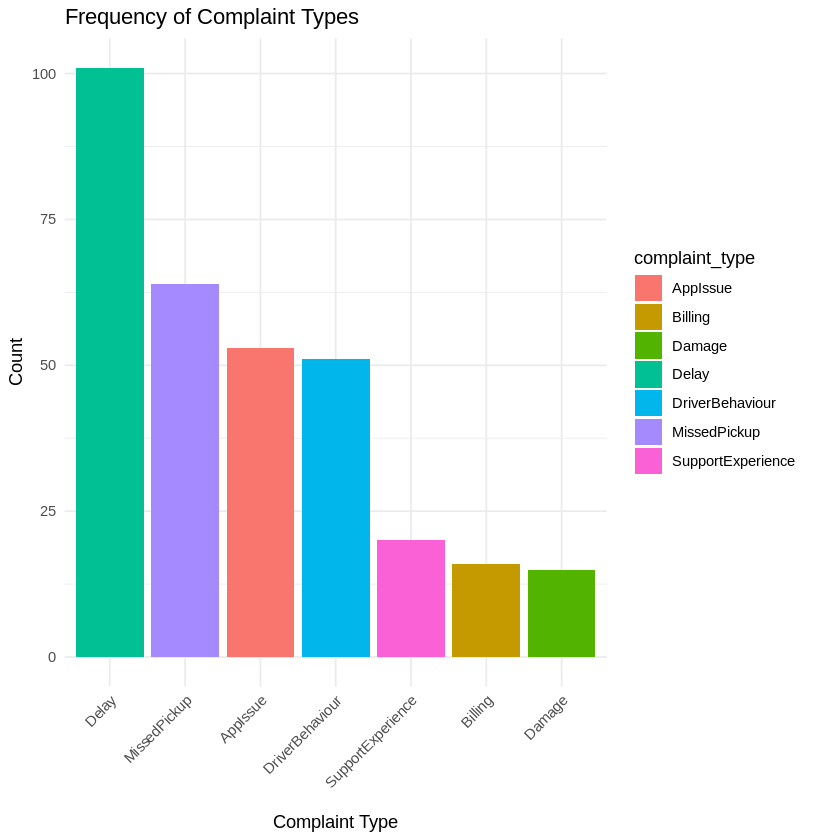

In [17]:
ggplot(complaints,
       aes(x = reorder(complaint_type, complaint_type, function(x) -length(x)),
           fill = complaint_type)) +
  geom_bar() +
  labs(title = "Frequency of Complaint Types",
       x = "Complaint Type", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

SQL in R

In [18]:
install.packages(c('sqldf','ggplot2','dplyr','tidyr','lubridate','scales'))
library(sqldf)
library(ggplot2)
library(dplyr)
library(tidyr)
library(lubridate)
library(scales)

customers  <- read.csv('customers.csv', stringsAsFactors = FALSE)
orders     <- read.csv('orders.csv', stringsAsFactors = FALSE)
deliveries <- read.csv('deliveries.csv', stringsAsFactors = FALSE)
drivers    <- read.csv('drivers.csv', stringsAsFactors = FALSE)
vehicles   <- read.csv('vehicles.csv', stringsAsFactors = FALSE)
hubs       <- read.csv('hubs.csv', stringsAsFactors = FALSE)
complaints <- read.csv('complaints.csv', stringsAsFactors = FALSE)
incidents  <- read.csv('incidents.csv', stringsAsFactors = FALSE)
app_events <- read.csv('app_events.csv', stringsAsFactors = FALSE)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



CRUD operations in R

Create
A new complaint record can be added to the complaints table as a test of insert-style behaviour.

In [19]:
new_order <- data.frame(
  order_id = "O2001",
  customer_id = "C0120",
  service_type = "Parcel",
  order_created_at = "2026-04-18 09:30:00",
  promised_window_hours = 4,
  pickup_zone = "NORTH",
  dropoff_zone = "CENTRAL",
  priority_level = "High",
  order_value = 84.50,
  booking_channel = "App",
  special_handling_flag = 1
)

orders <- rbind(orders, new_order)

sqldf("
SELECT order_id, customer_id, service_type, order_value
FROM orders
WHERE order_id = 'O2001'
")

order_id,customer_id,service_type,order_value
<chr>,<chr>,<chr>,<dbl>
O2001,C0120,Parcel,84.5


Read The read operation retrieves critical app booked orders.

In [20]:
sqldf("
SELECT order_id, service_type, priority_level, order_value
FROM orders
WHERE order_value > 150
  AND booking_channel = 'App'
ORDER BY order_value DESC
LIMIT 2
")

order_id,service_type,priority_level,order_value
<chr>,<chr>,<chr>,<dbl>
O00980,Parcel,Medium,510.06
O00529,Retail,Medium,355.62


UPDATE
This example updates a derived status label for very delayed complaints.

In [21]:
complaints$service_flag <- ifelse(
  complaints$resolution_days > 14 & complaints$status != "Closed",
  "NeedsEscalation",
  "Normal"
)

sqldf("
SELECT service_flag, COUNT(*) AS total_cases
FROM complaints
GROUP BY service_flag
")

service_flag,total_cases
<chr>,<int>
NeedsEscalation,34
Normal,286


Delete
This example removes the temporary test order.

In [22]:
orders <- orders[orders$order_id != "O2001", ]

sqldf("
SELECT COUNT(*) AS remaining_orders
FROM orders
")

remaining_orders
<int>
1250


Analytical SQL Queries in R

Ghost Order Detection

In [44]:
# ── Query 1: Ghost orders (orders with no delivery record) ───────────────
ghost_orders <- sqldf(
  "SELECT o.order_id,
          o.service_type,
          o.pickup_zone,
          o.order_value,
          o.priority_level
   FROM orders o
   LEFT JOIN deliveries d ON o.order_id = d.order_id
   WHERE d.delivery_id IS NULL
   ORDER BY o.order_value DESC"
)
cat('Ghost orders (no delivery record):', nrow(ghost_orders), '\n')
cat('Ghost rate:', round(nrow(ghost_orders)/nrow(orders)*100,1), '%\n')
# Service type breakdown of ghost orders
ghost_by_type <- sqldf(
  "SELECT service_type, COUNT(*) AS count,
          ROUND(AVG(order_value),2) AS avg_value
   FROM ghost_orders GROUP BY service_type ORDER BY count DESC"
)
print(ghost_by_type)


Ghost orders (no delivery record): 300 
Ghost rate: 24 %
  service_type count avg_value
1    Passenger    79     92.38
2       Parcel    78     80.13
3       Retail    73     99.85
4     Business    39     75.42
5      Medical    31     89.26


Service Profitability: Revenue vs. Failure Rate

In [45]:
# ── Query 2: Revenue and failure rate by service type ────────────────────
service_profit <- sqldf(
  "SELECT o.service_type,
          COUNT(o.order_id)                              AS total_orders,
          ROUND(SUM(o.order_value), 2)                   AS total_revenue,
          ROUND(AVG(o.order_value), 2)                   AS avg_order_value,
          ROUND(SUM(d.fuel_or_charge_cost), 2)           AS total_fuel_cost,
          SUM(CASE WHEN d.delivery_status = 'Failed'
                   THEN 1 ELSE 0 END)                   AS failed_count,
          ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed'
                            THEN 1 ELSE 0 END) /
                COUNT(o.order_id), 2)                   AS failure_rate_pct
   FROM orders o
   LEFT JOIN deliveries d ON o.order_id = d.order_id
   GROUP BY o.service_type
   ORDER BY failure_rate_pct DESC"
)
print(service_profit)


  service_type total_orders total_revenue avg_order_value total_fuel_cost
1     Business          165      15220.43           92.25         1655.91
2      Medical          139      12111.93           87.14         1379.48
3    Passenger          341      32761.11           96.07         3248.56
4       Retail          297      26734.06           90.01         2906.27
5       Parcel          308      26985.62           87.62         3009.01
  failed_count failure_rate_pct
1           25            15.15
2           16            11.51
3           38            11.14
4           28             9.43
5           25             8.12


Hub Performance: Aggregated Failure and Override Metrics

In [51]:

# ── Query 3: Hub-level failure, overrides, and complaints ────────────────
hub_perf <- sqldf(
  "SELECT d.hub_id,
          COUNT(d.delivery_id)                          AS total_dispatches,
          SUM(CASE WHEN d.delivery_status='Failed'
                   THEN 1 ELSE 0 END)                  AS failed,
          ROUND(100.0 * SUM(CASE WHEN d.delivery_status='Failed'
                   THEN 1 ELSE 0 END) /
                COUNT(d.delivery_id), 1)               AS fail_pct,
          ROUND(AVG(d.manual_route_override_count),2)  AS avg_overrides,
          ROUND(AVG(d.customer_rating_post_delivery),2) AS avg_rating,
          COUNT(c.complaint_id)                        AS complaints,
          ROUND(SUM(c.compensation_amount),2)          AS total_compensation
   FROM deliveries d
   LEFT JOIN orders o ON d.order_id = o.order_id
   LEFT JOIN complaints c ON d.order_id = c.order_id
   GROUP BY d.hub_id
   HAVING COUNT(d.delivery_id) >= 10
   ORDER BY fail_pct DESC"
)
print(hub_perf)


  hub_id total_dispatches failed fail_pct avg_overrides avg_rating complaints
1    H08              132     27     20.5          1.08       3.90         35
2    H05              117     23     19.7          0.94       3.68         30
3    H06              106     15     14.2          0.92       3.89         23
4    H01              142     18     12.7          1.02       3.84         32
5    H04              129     16     12.4          0.87       3.90         28
6    H07              118     14     11.9          1.04       3.89         33
7    H02              108     10      9.3          0.93       3.96         18
8    H03              121     11      9.1          0.89       3.90         33
  total_compensation
1             743.27
2             729.47
3             484.58
4             575.60
5             560.26
6             669.51
7             269.58
8             594.12


Mathematical Functions: Cost Efficiency per Kilometre

In [50]:
# ── Query 4: Cost efficiency — fuel cost per km by status ────────────────
cost_eff <- sqldf("
SELECT
    delivery_status,
    COUNT(*) AS total_deliveries,
    ROUND(SUM(fuel_or_charge_cost), 2) AS total_cost,
    ROUND(SUM(route_distance_km), 2) AS total_distance,
    ROUND(SUM(fuel_or_charge_cost) / SUM(route_distance_km), 3) AS cost_per_km,
    ROUND(AVG(fuel_or_charge_cost / route_distance_km), 3) AS avg_row_cost_per_km
FROM deliveries
WHERE route_distance_km > 0
GROUP BY delivery_status
ORDER BY cost_per_km DESC
")
print(cost_eff)

delivery_status,total_deliveries,total_cost,total_distance,cost_per_km,avg_row_cost_per_km
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Failed,132,1735.53,1764.22,0.984,1.355
OnTime,616,7809.68,8486.24,0.920,1.225
Delayed,202,2654.02,2963.39,0.896,1.314


Driver Performance: Training Score vs. Operational Metrics

In [69]:
# ── Query 5: Driver training vs. overrides and rating ────────────────────
driver_perf <- sqldf("
SELECT
    dr.driver_id,
    dr.base_zone,
    ROUND(AVG(dr.training_score), 2) AS avg_training_score,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    COUNT(i.incident_id) AS incident_count
FROM drivers dr
LEFT JOIN deliveries d
    ON dr.driver_id = d.driver_id
LEFT JOIN incidents i
    ON d.delivery_id = i.delivery_id
GROUP BY dr.driver_id, dr.base_zone
ORDER BY avg_training_score DESC
LIMIT 15
")
# Training tier comparison
tier_compare <- sqldf(
  "SELECT
     CASE WHEN dr.training_score < 65   THEN 'Low (<65)'
          WHEN dr.training_score < 85   THEN 'Mid (65-84)'
          ELSE                               'High (85+)'
     END AS training_tier,
     COUNT(DISTINCT dr.driver_id)       AS driver_count,
     ROUND(AVG(d.manual_route_override_count),3) AS avg_overrides,
     ROUND(AVG(d.customer_rating_post_delivery),3) AS avg_cust_rating
   FROM drivers dr
   LEFT JOIN deliveries d ON dr.driver_id = d.driver_id
   GROUP BY training_tier
   ORDER BY avg_overrides DESC"
)
tier_compare


training_tier,driver_count,avg_overrides,avg_cust_rating
<chr>,<int>,<dbl>,<dbl>
Low (<65),29,1.006,3.875
Mid (65-84),105,0.972,3.869
High (85+),36,0.933,3.845


Data Manipulation and Transformation in R

Deriving time-based features

In [70]:
orders$order_created_at <- as.POSIXct(orders$order_created_at, format = "%Y-%m-%d %H:%M:%S")
orders$order_hour <- as.integer(format(orders$order_created_at, "%H"))
orders$order_day <- format(orders$order_created_at, "%A")
orders$high_value_flag <- ifelse(orders$order_value >= 100, "HighValue", "Standard")

Creating operational flags and efficiency measures

In [71]:
deliveries <- deliveries %>%
  mutate(
    delay_flag = ifelse(delivery_status == "Delayed", 1, 0),
    failure_flag = ifelse(delivery_status == "Failed", 1, 0),
    cost_per_km = fuel_or_charge_cost / route_distance_km
  )

Data Visualisation in R

Delivery Status Distribution

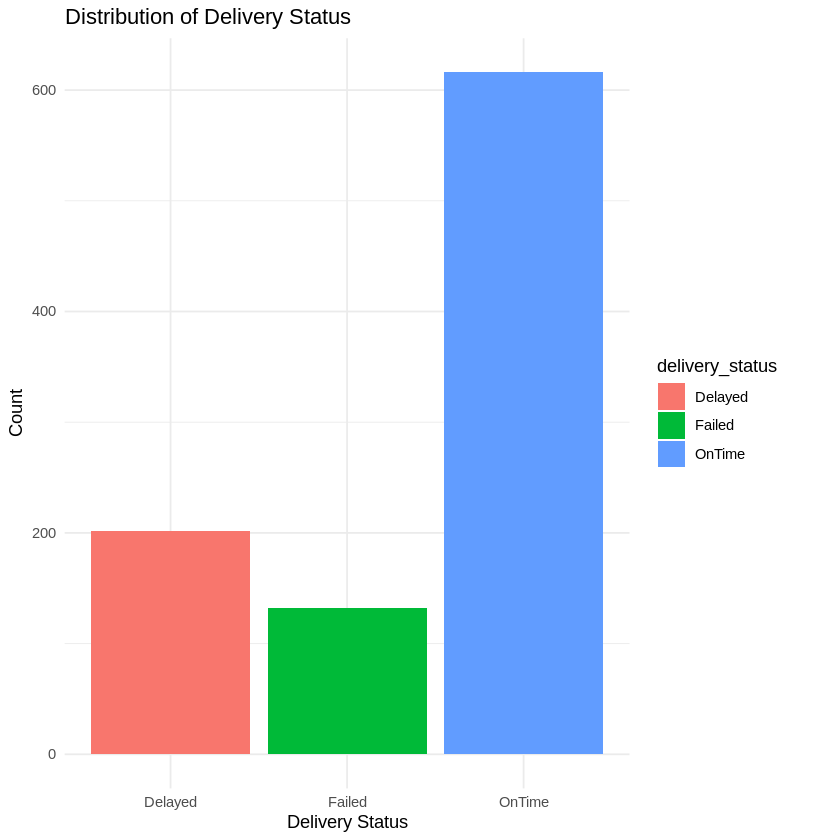

In [72]:
ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  theme_minimal() +
  labs(
    title = "Distribution of Delivery Status",
    x = "Delivery Status",
    y = "Count"
  )

Distribution of order values

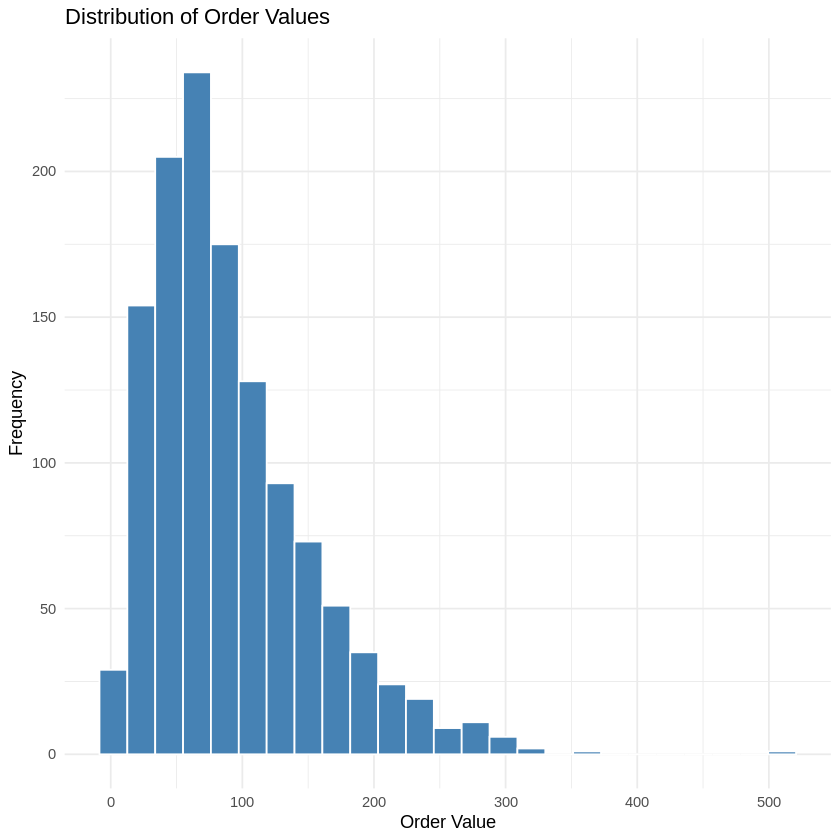

In [73]:
ggplot(orders, aes(x = order_value)) +
  geom_histogram(bins = 25, fill = "steelblue", color = "white") +
  theme_minimal() +
  labs(
    title = "Distribution of Order Values",
    x = "Order Value",
    y = "Frequency"
  )

Complaint type frequency

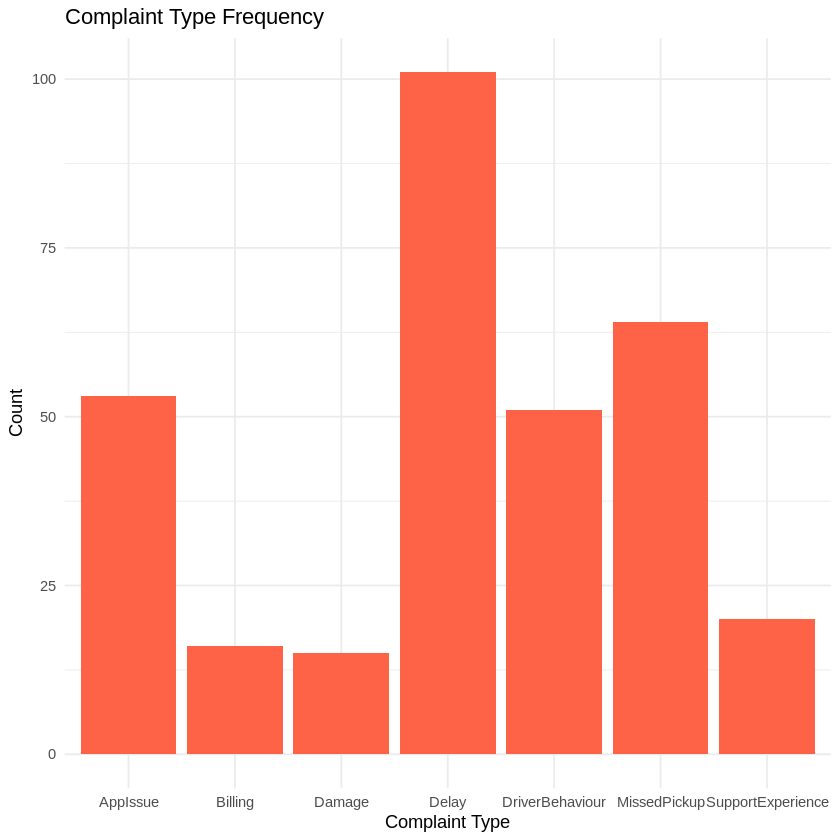

In [74]:
ggplot(complaints, aes(x = complaint_type)) +
  geom_bar(fill = "tomato") +
  theme_minimal() +
  labs(
    title = "Complaint Type Frequency",
    x = "Complaint Type",
    y = "Count"
  )